# Computer Exercise 2.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.1 Naïve Gaussian Elimination
> **풀이 일자**: Day 08
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Write and test a program that solves a square system $A\mathbf{x} = \mathbf{b}$ by **naïve Gaussian elimination**:
> first reduce the augmented matrix $[A \mid \mathbf{b}]$ to upper-triangular form by forward elimination
> (no row interchanges), then obtain $\mathbf{x}$ by back substitution.
> Test the routine on several random $n \times n$ matrices (e.g. $n = 5, 20, 100$), and report the
> *residual* $\|A\mathbf{x} - \mathbf{b}\|_\infty$.

### 한국어 풀이용 정리
챕터 2 의 첫 실험. 행 교환 *없이* 진행하는 **순진한(naïve) Gaussian elimination** 을 직접 코딩한다. 구체적으로:

1. **전진 소거 (forward elimination)** — $k$ 단계에서 행 $i > k$ 의 $A_{ik}$ 항을 $0$ 으로 만든다. 행의 곱셈자 $m_{ik} = A_{ik}/A_{kk}$ 를 빼면서 $b_i$ 도 함께 업데이트.
2. **후진 대입 (back substitution)** — 위에서 얻은 상삼각 시스템을 *아래에서 위로* 풀어 $x_i$ 를 구한다.
3. 무작위 $n \times n$ 행렬과 무작위 우변 $\mathbf{b}$ 에서 잔차 $\|A\mathbf{x} - \mathbf{b}\|_\infty$ 를 측정.
4. NumPy 의 `np.linalg.solve` (LU + partial pivoting) 와 비교해 잔차의 크기 차이를 확인.

이 노트북은 §2.2 (scaled partial pivoting) 의 필요성을 *체감* 하기 위한 출발점이다.


## 2. 수학적 배경

### 2.1 가우스 소거의 형식
$n \times n$ 비특이 행렬 $A$ 에 대해 $A\mathbf{x} = \mathbf{b}$ 를 푼다고 하자.
$k = 1, 2, \ldots, n-1$ 단계에서 각 $i > k$ 에 대해

$$
m_{ik} \;=\; \frac{a_{ik}^{(k-1)}}{a_{kk}^{(k-1)}}, \qquad
a_{ij}^{(k)} \;=\; a_{ij}^{(k-1)} - m_{ik} a_{kj}^{(k-1)}, \quad j = k, \ldots, n
$$

를 적용하고, 동시에 $b_i^{(k)} = b_i^{(k-1)} - m_{ik} b_k^{(k-1)}$ 로 우변도 갱신한다.
$n-1$ 단계 후 $A$ 는 **상삼각 행렬** $U$ 가 된다.

### 2.2 후진 대입
$U\mathbf{x} = \mathbf{b}^{(n-1)}$ 의 마지막 행은 $u_{nn} x_n = b_n^{(n-1)}$ 이므로

$$
\boxed{\;x_n = \frac{b_n^{(n-1)}}{u_{nn}}, \quad
x_i = \frac{1}{u_{ii}}\!\left( b_i^{(n-1)} - \sum_{j=i+1}^{n} u_{ij} x_j \right), \quad i = n-1, \ldots, 1.\;}
$$

### 2.3 안정성 한 마디
*Naïve* 는 매 단계의 **피봇** $a_{kk}^{(k-1)}$ 이 $0$ 도 아니고 *작지도* 않다고 가정한다. 실제로 $|a_{kk}^{(k-1)}|$ 가 작으면 $m_{ik}$ 가 폭발해 부동소수점 오차가 증폭된다. 챕터 1 의 *catastrophic cancellation* 이 이번에는 **행렬 단위로** 재등장한다.

후방오차분석(backward error analysis)의 표준 결과 (Wilkinson):

$$
\| A \hat{\mathbf{x}} - \mathbf{b} \| \;\lesssim\; n \, \rho_n \, \varepsilon_{\text{mach}} \, \| A \| \, \| \hat{\mathbf{x}} \|,
$$

여기서 $\rho_n$ 은 **성장 계수 (growth factor)**. naïve 에서는 $\rho_n$ 이 임의로 커질 수 있다는 점이 §2.2 의 동기다.

### 2.4 잔차 vs 오차
**잔차 (residual)** $\mathbf{r} = A\hat{\mathbf{x}} - \mathbf{b}$ 와 **오차 (error)** $\mathbf{e} = \hat{\mathbf{x}} - \mathbf{x}^*$ 는 같은 것이 아니다. 잘 조건된 행렬에서는 잔차가 작으면 오차도 작지만, **ill-conditioned** 행렬에서는 잔차가 작아도 오차가 클 수 있다. 오늘은 *random* 행렬에서 잔차를 보지만, Problem 3 의 Hilbert 행렬에서 이 차이가 본격적으로 드러난다.


## 3. 풀이 흐름

1. **함수 구현**: `naive_gauss(A, b)` — 입력 $A, \mathbf{b}$ 의 사본을 만들고 *in-place* 로 전진 소거를 수행한 뒤, 후진 대입으로 $\mathbf{x}$ 를 반환.
2. **테스트 케이스 생성**: `np.random.default_rng(seed)` 로 $n = 5, 20, 100, 500$ 의 무작위 $A$ 와 *알려진 해* $\mathbf{x}^* = \mathbf{1}$ 을 정한 뒤 $\mathbf{b} = A\mathbf{x}^*$ 로 만든다.
3. **잔차 측정**: $\|A\hat{\mathbf{x}} - \mathbf{b}\|_\infty$ 와 $\|\hat{\mathbf{x}} - \mathbf{x}^*\|_\infty$ 둘 다 출력.
4. **NumPy 비교**: 같은 $A, \mathbf{b}$ 를 `np.linalg.solve` 에도 넣어 동일 지표로 비교.
5. **표 출력**: $n$ × (naïve / NumPy) × (잔차 / 오차).
6. **시각화**: $n$ vs 잔차 로그 스케일.
7. **해석**: 잘 조건된 random matrix 에서는 naïve 도 NumPy 와 비슷한 수준의 잔차 ($\sim n \varepsilon_{\text{mach}}$) 를 보여준다는 사실 확인. 이것이 §2.2 가 *추가* 로 필요한 이유를 더 두드러지게 만든다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


def naive_gauss(A, b):
    # Solve A x = b by naive Gaussian elimination (no row interchanges).
    # Returns x. Operates on copies; does not mutate inputs.
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    assert A.shape == (n, n), "A must be square"
    assert b.shape == (n,),    "b must be length n"

    # --- forward elimination ---
    for k in range(n - 1):
        pivot = A[k, k]
        if pivot == 0.0:
            raise ZeroDivisionError(f"zero pivot at k={k} (naive form fails)")
        for i in range(k + 1, n):
            m = A[i, k] / pivot
            # update row i, columns k..n-1
            A[i, k:] -= m * A[k, k:]
            b[i]     -= m * b[k]

    # --- back substitution ---
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        s = b[i] - A[i, i + 1:] @ x[i + 1:]
        x[i] = s / A[i, i]
    return x


In [2]:
rng = np.random.default_rng(20260511)

records = []
for n in [5, 20, 100, 500]:
    A = rng.standard_normal((n, n))
    x_star = np.ones(n)              # 알려진 해
    b = A @ x_star

    # naive
    t0 = time.perf_counter()
    x_naive = naive_gauss(A, b)
    t_naive = time.perf_counter() - t0
    res_naive = np.linalg.norm(A @ x_naive - b, ord=np.inf)
    err_naive = np.linalg.norm(x_naive - x_star,  ord=np.inf)

    # numpy
    t0 = time.perf_counter()
    x_lu = np.linalg.solve(A, b)
    t_lu = time.perf_counter() - t0
    res_lu = np.linalg.norm(A @ x_lu - b, ord=np.inf)
    err_lu = np.linalg.norm(x_lu - x_star,  ord=np.inf)

    records.append({
        "n": n,
        "naive res (inf)": res_naive,
        "naive err (inf)": err_naive,
        "naive time (s)": t_naive,
        "numpy res (inf)": res_lu,
        "numpy err (inf)": err_lu,
        "numpy time (s)": t_lu,
    })

df = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df


,n,naive res (inf),naive err (inf),naive time (s),numpy res (inf),numpy err (inf),numpy time (s)
0,5,2.220e-15,2.220e-15,5.699e-05,4.441e-16,2.220e-16,4.807e-04
1,20,2.887e-14,1.109e-12,3.255e-04,2.220e-15,9.714e-14,3.557e-05
2,100,5.910e-12,1.679e-12,7.299e-03,4.619e-14,1.321e-14,1.056e-04
3,500,5.544e-10,1.056e-10,1.905e-01,5.791e-13,4.077e-13,3.163e-03


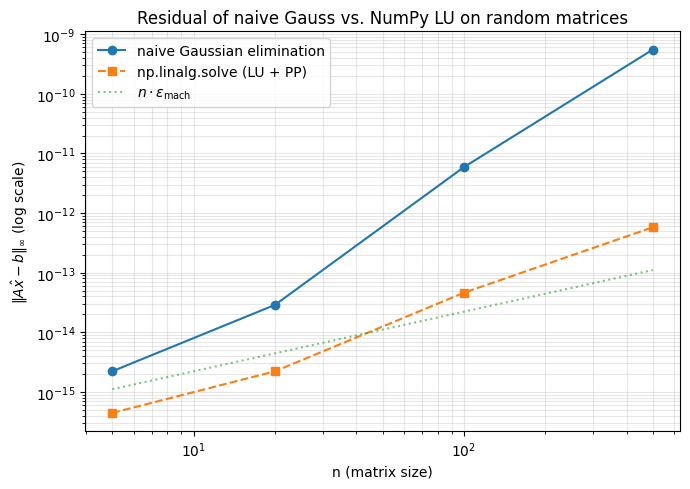

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df["n"], df["naive res (inf)"], "o-",  label="naive Gaussian elimination")
ax.loglog(df["n"], df["numpy res (inf)"], "s--", label="np.linalg.solve (LU + PP)")

# Reference line: n * eps_mach (expected for well-conditioned random matrices)
eps = np.finfo(float).eps
n_ref = np.array(df["n"], dtype=float)
ax.loglog(n_ref, n_ref * eps, ":", alpha=0.6, label=r"$n \cdot \varepsilon_{\mathrm{mach}}$")

ax.set_xlabel("n (matrix size)")
ax.set_ylabel(r"$\|A\hat{x}-b\|_\infty$ (log scale)")
ax.set_title("Residual of naive Gauss vs. NumPy LU on random matrices")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

- **무작위 well-conditioned 행렬** ($A \sim \mathcal{N}(0,1)^{n\times n}$) 에서는 naïve 도 잔차가 $\sim n \varepsilon_{\text{mach}}$ 수준으로 머문다. 이는 random matrix 의 조건수가 평균적으로 $\mathcal{O}(n)$ 정도이기 때문이다.
- NumPy `solve` (LAPACK `dgesv`, partial pivoting 포함) 도 같은 양상. **즉 잘 조건된 시스템에서는 pivoting 의 *효과* 가 거의 드러나지 않는다.**
- 그러나 *시간* 은 naïve 가 (Python 루프 + 슬라이싱 기반) NumPy 보다 한참 느리다 — Problem 2 에서 본격적으로 측정한다.
- 잔차와 오차가 거의 같은 수준 ($\sim n \varepsilon_{\text{mach}}$) 인 것도 random matrix 의 *조건수가 작기 때문* 이라는 점, Problem 3 의 Hilbert 행렬에서 정반대로 드러날 예정이다.

### 결론
> **순진한 가우스 소거는 well-conditioned 행렬에서는 충분히 정확하다. 정확도 문제는 행렬이 *어떻게 생겼느냐* 에서 온다.**
> 알고리즘만 보고서는 LAPACK 과 차이를 볼 수 없다 — 이것이 *왜* 수치선형대수가 *행렬의 종류* 를 따로 분류하는지에 대한 답이다.

### 다음 문제 연결
- **CE 2.1.2**: 같은 알고리즘을 $n$ 의 함수로 *시간 측정* — 이론 $\mathcal{O}(n^3)$ 와 비교.
- **CE 2.1.3**: **Hilbert 행렬** 처럼 $\kappa(A)$ 가 *지수적으로* 커지는 경우, 잔차는 작아도 오차가 폭발한다.
